# Exploratory Analysis — Milan Internet Traffic

Distribution of total traffic across squares, first-two-weeks time series for five areas, and stationarity / autocorrelation analysis for the busiest square (5161).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

def _find_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, here.parent, Path("/Users/mac/formative1")]:
        if (cand / "data" / "processed" / "per_square_totals.parquet").exists():
            return cand
    raise FileNotFoundError("Could not locate formative1 project root")

ROOT = _find_root()
PROC = ROOT / "data" / "processed"
FIG = ROOT / "report" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("ROOT =", ROOT)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

SQUARES = [5161, 5059, 5259, 4159, 4556]
LABELS = {
    5161: "5161 (highest)",
    5059: "5059 (2nd)",
    5259: "5259 (3rd)",
    4159: "4159 (assigned)",
    4556: "4556 (assigned)",
}

ROOT = /Users/mac/formative1


## 1. Distribution of total Internet traffic across geographical areas

Totals come from `per_square_totals.parquet` (full 10,000 squares over the ~2-month window).  
`square_totals_summary.csv` only stores the five EDA focus squares.

In [2]:
totals = pd.read_parquet(PROC / "per_square_totals.parquet")["total_internet"]
assert len(totals) == 10_000

summary = {
    "n_squares": int(totals.shape[0]),
    "mean": float(totals.mean()),
    "std": float(totals.std()),
    "min": float(totals.min()),
    "p25": float(totals.quantile(0.25)),
    "median": float(totals.median()),
    "p75": float(totals.quantile(0.75)),
    "p95": float(totals.quantile(0.95)),
    "p99": float(totals.quantile(0.99)),
    "max": float(totals.max()),
    "skewness": float(totals.skew()),
    "excess_kurtosis": float(totals.kurtosis()),
    "top_median_ratio": float(totals.max() / totals.median()),
    "top_bottom_ratio": float(totals.max() / totals.min()) if totals.min() > 0 else np.inf,
}
summary_df = pd.Series(summary, name="value").to_frame()
print(summary_df.to_string(float_format=lambda x: f"{x:.4g}"))
summary_df

                     value
n_squares            1e+04
mean             5.553e+05
std              8.926e+05
min                  213.6
p25              1.181e+05
median           2.779e+05
p75              5.779e+05
p95              2.172e+06
p99              4.699e+06
max              1.274e+07
skewness             4.265
excess_kurtosis      25.52
top_median_ratio     45.85
top_bottom_ratio 5.964e+04


,value
n_squares,1.000000e+04
mean,5.552894e+05
std,8.925957e+05
min,2.136265e+02
p25,1.181020e+05
median,2.778711e+05
p75,5.778956e+05
p95,2.171807e+06
p99,4.698732e+06
max,1.274006e+07


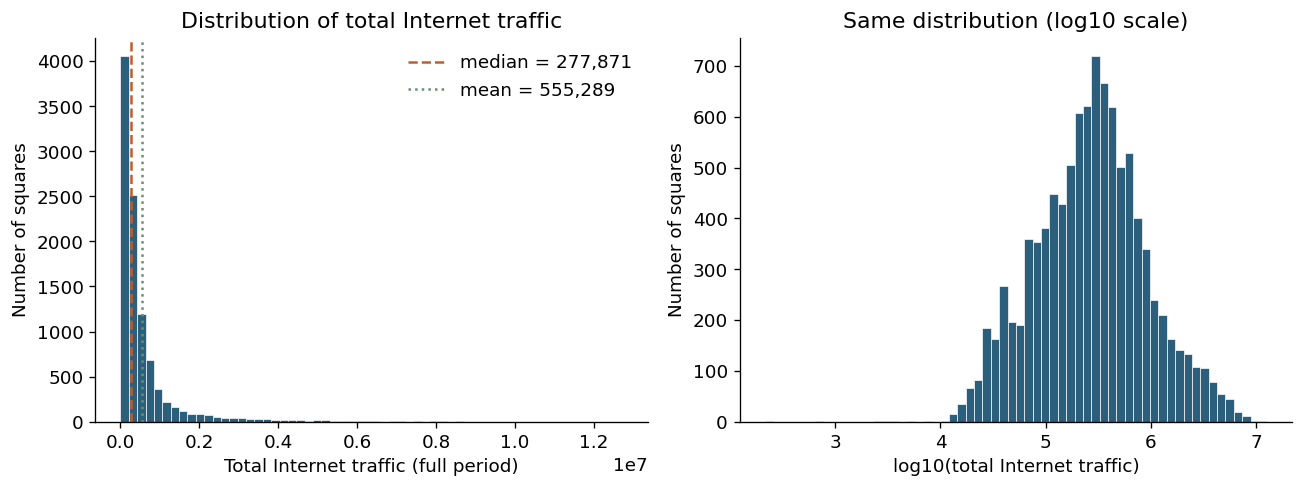

Saved /Users/mac/formative1/report/figures/total_internet_traffic_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].hist(totals, bins=60, color="#2c5f7c", edgecolor="white", linewidth=0.4)
axes[0].axvline(totals.median(), color="#c45c26", ls="--", lw=1.5, label=f"median = {totals.median():,.0f}")
axes[0].axvline(totals.mean(), color="#6b8f71", ls=":", lw=1.5, label=f"mean = {totals.mean():,.0f}")
axes[0].set_xlabel("Total Internet traffic (full period)")
axes[0].set_ylabel("Number of squares")
axes[0].set_title("Distribution of total Internet traffic")
axes[0].legend(frameon=False)

log_tot = np.log10(totals.clip(lower=totals[totals > 0].min()))
axes[1].hist(log_tot, bins=60, color="#2c5f7c", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("log10(total Internet traffic)")
axes[1].set_ylabel("Number of squares")
axes[1].set_title("Same distribution (log10 scale)")

fig.tight_layout()
out = FIG / "total_internet_traffic_distribution.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

### Discussion notes (distribution)

- The distribution is **strongly right-skewed**: a small number of squares carry orders of magnitude more traffic than the typical square (see `top_median_ratio` and skewness above).
- Mean ≫ median, so the arithmetic mean is pulled by hotspot squares (city centre / transport hubs).
- Most squares sit in a relatively compact lower band; the upper tail is long — forecasting difficulty and absolute error will concentrate in high-traffic areas.
- Implication for modelling: evaluate on absolute metrics (MAE/RMSE) *and* relative ones (MAPE), and treat high- vs mid-traffic squares as different regimes.

## 2. First two weeks (1–14 Nov 2013) — five geographical areas

In [4]:
table = pq.read_table(
    PROC / "internet_traffic.parquet",
    filters=[("square_id", "in", SQUARES)],
)
ts = table.to_pandas()
ts["datetime"] = pd.to_datetime(ts["timestamp"], unit="ms", utc=True).dt.tz_convert("Europe/Rome")

start = pd.Timestamp("2013-11-01", tz="Europe/Rome")
end = pd.Timestamp("2013-11-15", tz="Europe/Rome")  # exclusive → through Nov 14
two_weeks = ts[(ts["datetime"] >= start) & (ts["datetime"] < end)].copy()
two_weeks = two_weeks.sort_values(["square_id", "datetime"])

print(two_weeks.groupby("square_id").agg(
    n=("internet", "size"),
    mean=("internet", "mean"),
    max=("internet", "max"),
).round(2))

              n         mean          max
square_id                                
4159       2016   311.350006   851.049988
4556       2016   592.700012  1868.739990
5059       2016  1330.619995  4182.759766
5161       2016  1483.550049  8044.069824
5259       2016  1293.500000  4262.899902


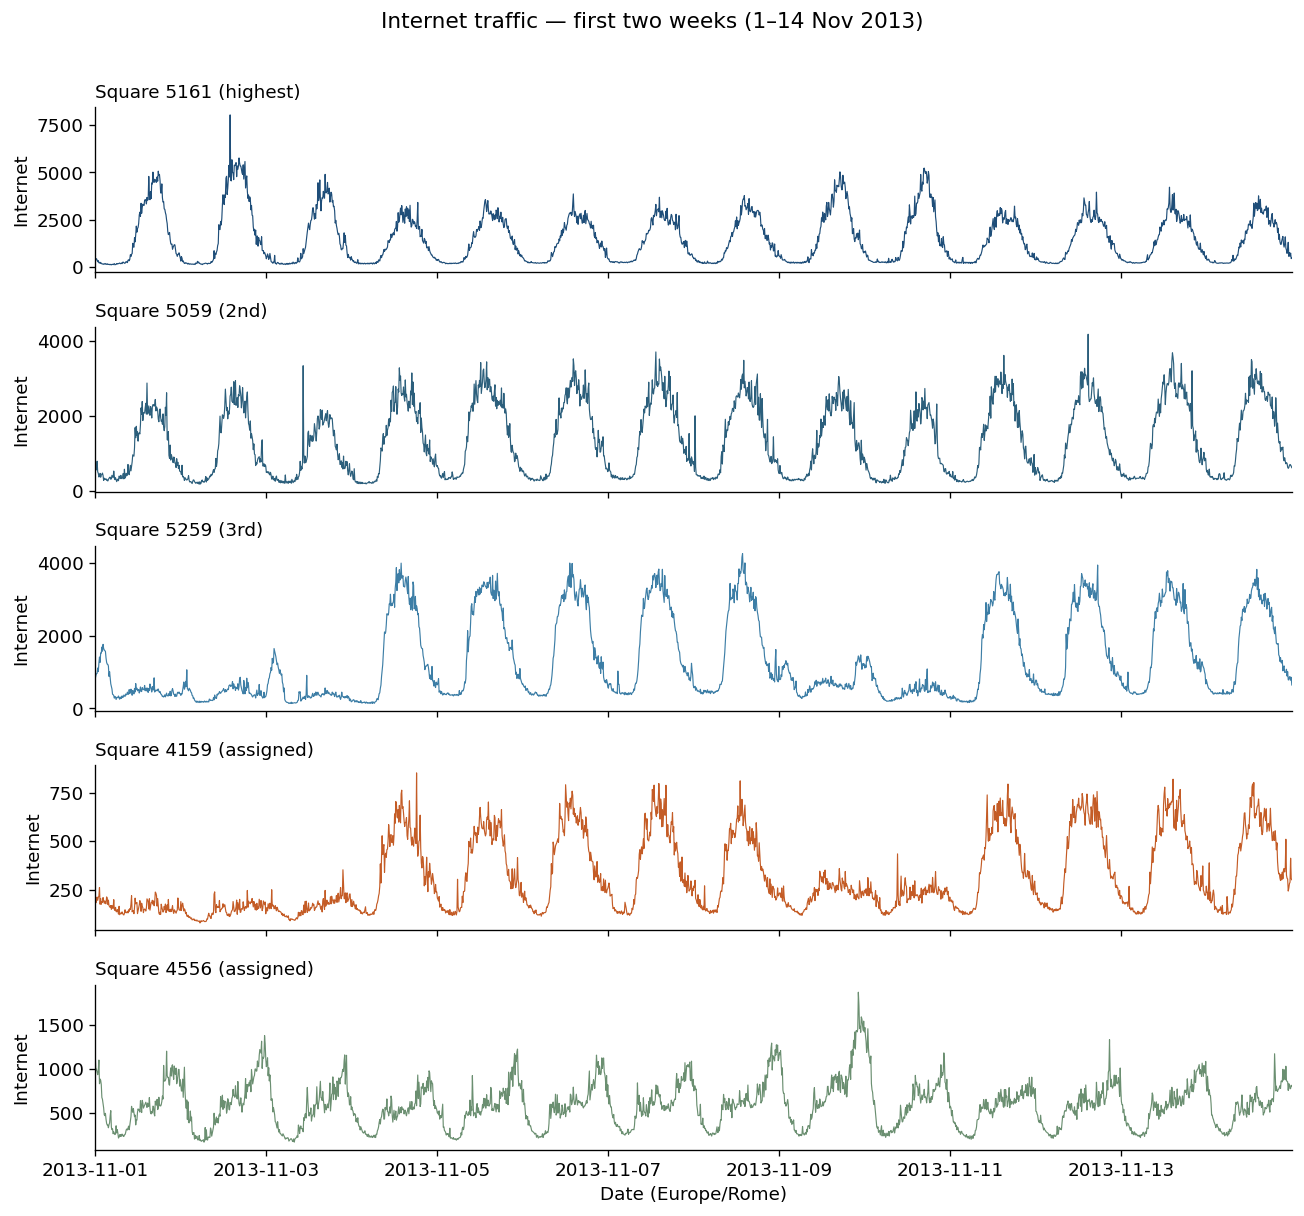

Saved /Users/mac/formative1/report/figures/timeseries_five_squares_nov1_14.png


In [5]:
fig, axes = plt.subplots(5, 1, figsize=(11, 10), sharex=True)
colors = {
    5161: "#1f4e79",
    5059: "#2c5f7c",
    5259: "#3d7ea6",
    4159: "#c45c26",
    4556: "#6b8f71",
}

for ax, sid in zip(axes, SQUARES):
    sub = two_weeks[two_weeks["square_id"] == sid]
    ax.plot(sub["datetime"], sub["internet"], color=colors[sid], lw=0.7)
    ax.set_ylabel("Internet")
    ax.set_title(f"Square {LABELS[sid]}", loc="left", fontsize=11)
    ax.set_xlim(start, end - pd.Timedelta(seconds=1))

axes[-1].set_xlabel("Date (Europe/Rome)")
fig.suptitle("Internet traffic — first two weeks (1–14 Nov 2013)", y=1.01, fontsize=13)
fig.tight_layout()
out = FIG / "timeseries_five_squares_nov1_14.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

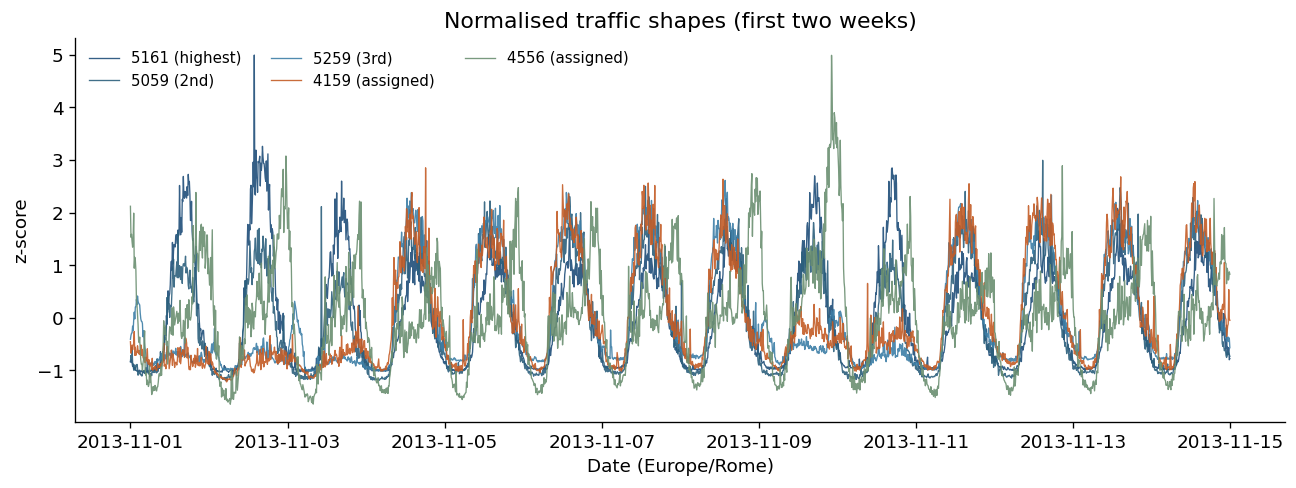

Saved /Users/mac/formative1/report/figures/timeseries_five_squares_nov1_14_normalized.png


In [6]:
# Overlay on a shared axis (normalised) to compare shape vs level
fig, ax = plt.subplots(figsize=(11, 4.2))
for sid in SQUARES:
    sub = two_weeks[two_weeks["square_id"] == sid].set_index("datetime")["internet"]
    norm = (sub - sub.mean()) / sub.std()
    ax.plot(norm.index, norm.values, lw=0.8, label=LABELS[sid], color=colors[sid], alpha=0.9)
ax.set_ylabel("z-score")
ax.set_xlabel("Date (Europe/Rome)")
ax.set_title("Normalised traffic shapes (first two weeks)")
ax.legend(frameon=False, ncol=3, fontsize=9)
fig.tight_layout()
out = FIG / "timeseries_five_squares_nov1_14_normalized.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

### Discussion notes (temporal dynamics)

- All five series show clear **diurnal cycles** (night-time troughs, daytime peaks).
- Top-three squares (5161, 5059, 5259) share similar periodicity but differ in amplitude; 5161 has the tallest peaks.
- Assigned squares 4159 and 4556 run at lower absolute levels; compare their normalised shapes to see whether seasonality structure still matches the hotspots.
- Weekend vs weekday differences (if visible in the two-week window) matter for train/test splits and for whether models need day-of-week features or a long enough lookback to capture weekly seasonality (7×144 = 1008 steps at 10-minute resolution).

## 3. Square 5161 — stationarity (ADF) and ACF / PACF

Uses the **full observation period** for 5161 so autocorrelation estimates are stable. ACF/PACF inform sequence length; ADF informs whether differencing / flexible nonlinear models are warranted.

In [7]:
s5161 = (
    ts[ts["square_id"] == 5161]
    .sort_values("datetime")
    .set_index("datetime")["internet"]
    .asfreq("10min")
)
# fill rare gaps (if any) for ADF/ACF on a regular grid
n_missing = int(s5161.isna().sum())
s5161 = s5161.interpolate(limit_direction="both")
print(f"Square 5161: {len(s5161):,} steps @ 10min | missing before interpolate: {n_missing}")
print(f"Range: {s5161.index.min()} → {s5161.index.max()}")

Square 5161: 8,928 steps @ 10min | missing before interpolate: 0
Range: 2013-11-01 00:00:00+01:00 → 2014-01-01 23:50:00+01:00


In [8]:
adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, adf_icbest = adfuller(
    s5161.values, autolag="AIC"
)
adf_rows = {
    "ADF statistic": adf_stat,
    "p-value": adf_p,
    "used lag": adf_lags,
    "n obs": adf_nobs,
    "IC best": adf_icbest,
}
for k, v in adf_crit.items():
    adf_rows[f"critical {k}"] = v

adf_table = pd.Series(adf_rows, name="value")
print(adf_table.to_frame().to_string())
adf_table.to_frame()

reject = adf_p < 0.05
print(
    "Conclusion: "
    + (
        "reject H0 — series looks stationary around its mean (no unit root) at 5%."
        if reject
        else "fail to reject H0 — evidence of a unit root; consider differencing or trend-aware models."
    )
)

                       value
ADF statistic     -19.031899
p-value             0.000000
used lag           36.000000
n obs            8891.000000
IC best        119174.327349
critical 1%        -3.431086
critical 5%        -2.861865
critical 10%       -2.566943
Conclusion: reject H0 — series looks stationary around its mean (no unit root) at 5%.


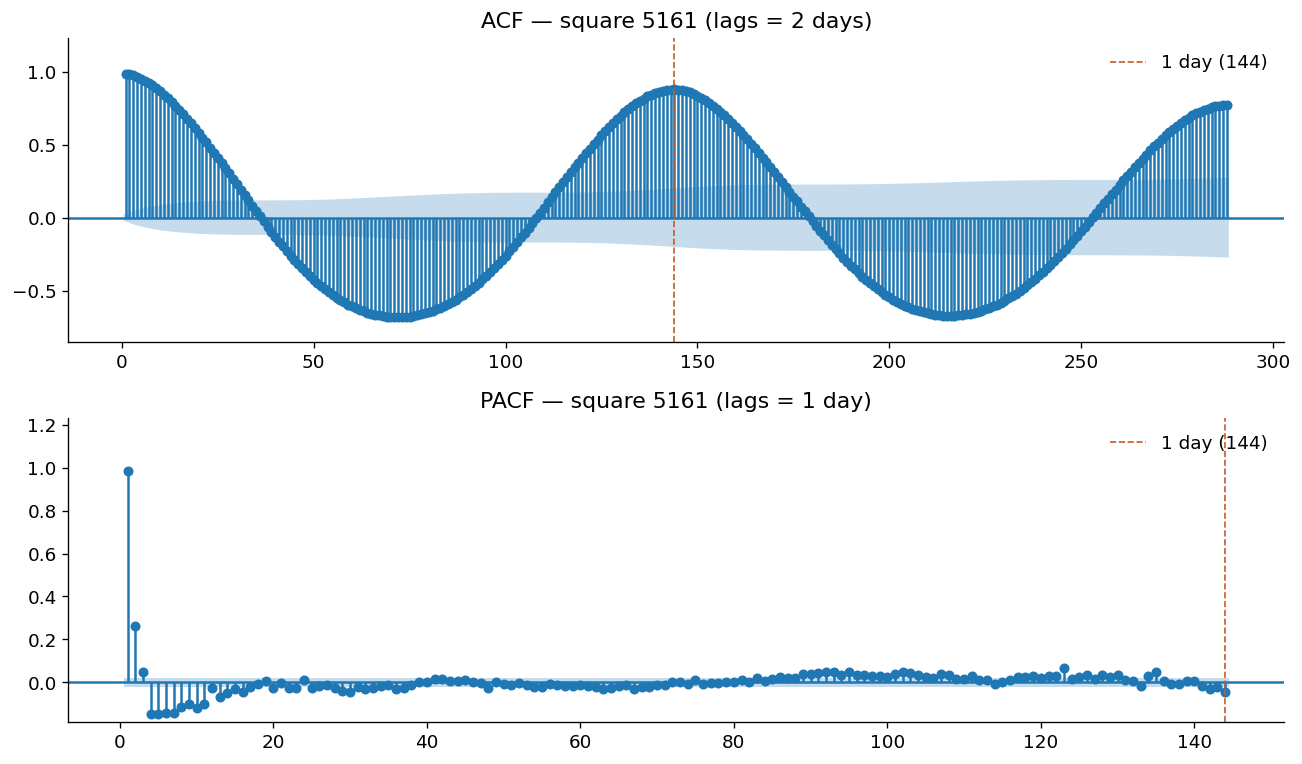

Saved /Users/mac/formative1/report/figures/square_5161_acf_pacf.png


In [9]:
# Daily seasonality at 10-min resolution: 24*6 = 144 steps
LAGS = 144 * 2  # two days of lags for ACF context

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5))
plot_acf(s5161, lags=LAGS, ax=axes[0], zero=False, auto_ylims=True)
axes[0].set_title("ACF — square 5161 (lags = 2 days)")
axes[0].axvline(144, color="#c45c26", ls="--", lw=1, label="1 day (144)")
axes[0].legend(frameon=False, loc="upper right")

plot_pacf(s5161, lags=min(144, LAGS), ax=axes[1], zero=False, method="ywm", auto_ylims=True)
axes[1].set_title("PACF — square 5161 (lags = 1 day)")
axes[1].axvline(144, color="#c45c26", ls="--", lw=1, label="1 day (144)")
axes[1].legend(frameon=False, loc="upper right")

fig.tight_layout()
out = FIG / "square_5161_acf_pacf.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

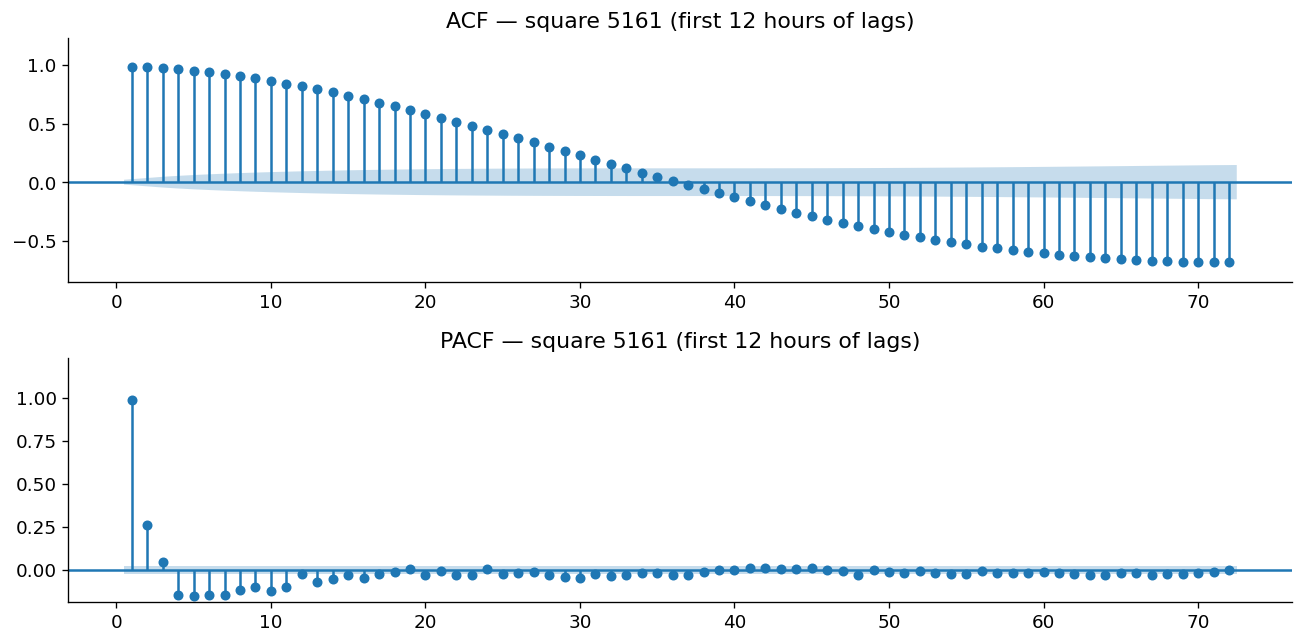

Saved /Users/mac/formative1/report/figures/square_5161_acf_pacf_short.png


In [10]:
# Zoomed ACF/PACF for short-range dependence (sequence-length design)
SHORT = 72  # 12 hours
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5))
plot_acf(s5161, lags=SHORT, ax=axes[0], zero=False, auto_ylims=True)
axes[0].set_title("ACF — square 5161 (first 12 hours of lags)")
plot_pacf(s5161, lags=SHORT, ax=axes[1], zero=False, method="ywm", auto_ylims=True)
axes[1].set_title("PACF — square 5161 (first 12 hours of lags)")
fig.tight_layout()
out = FIG / "square_5161_acf_pacf_short.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

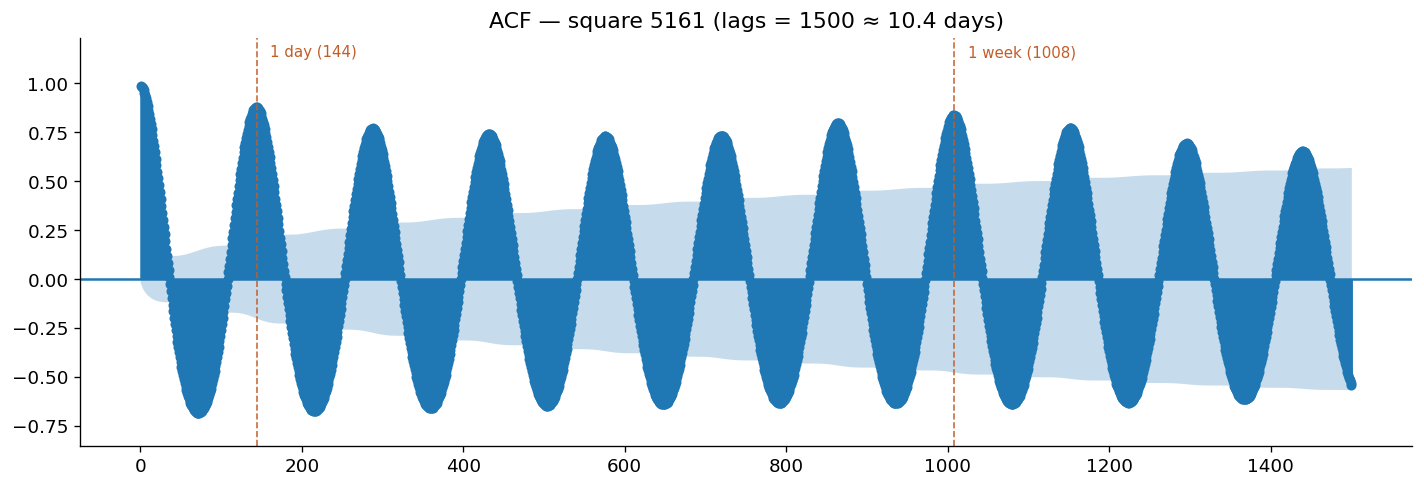

Saved /Users/mac/formative1/report/figures/square_5161_acf_weekly.png
  lag  144 (1.0 days): ACF = 0.8783
  lag  288 (2.0 days): ACF = 0.7696
  lag  720 (5.0 days): ACF = 0.7330
  lag  864 (6.0 days): ACF = 0.7978
  lag 1008 (7.0 days): ACF = 0.8377
  lag 1152 (8.0 days): ACF = 0.7717


In [11]:
# Extended ACF to probe weekly seasonality (7 × 144 = 1008)
WEEKLY_LAGS = 1500  # ≈ 10.4 days

fig, ax = plt.subplots(figsize=(12, 4.2))
plot_acf(s5161, lags=WEEKLY_LAGS, ax=ax, zero=False, auto_ylims=True, fft=True)
ax.set_title("ACF — square 5161 (lags = 1500 ≈ 10.4 days)")
for lag, label in [(144, "1 day"), (1008, "1 week")]:
    ax.axvline(lag, color="#c45c26", ls="--", lw=1, alpha=0.9)
    ymax = ax.get_ylim()[1]
    ax.annotate(
        f"{label} ({lag})",
        xy=(lag, ymax * 0.92),
        xytext=(8, 0),
        textcoords="offset points",
        fontsize=9,
        color="#c45c26",
    )
fig.tight_layout()
out = FIG / "square_5161_acf_weekly.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

from statsmodels.tsa.stattools import acf as _acf
_acf_vals = _acf(s5161, nlags=WEEKLY_LAGS, fft=True)
for lag in [144, 288, 720, 864, 1008, 1152]:
    print(f"  lag {lag:4d} ({lag/144:.1f} days): ACF = {_acf_vals[lag]:.4f}")


### Weekly seasonality evidence

Extending the ACF to **1500 lags (~10 days)** shows a clear secondary peak at **lag 1008** (7 × 144 = one week), with ACF ≈ **0.84**. That peak is a local maximum and sits above the surrounding daily multiples at 6 and 8 days (lags 864 and 1152). Together with the primary daily peak at lag 144 (ACF ≈ 0.88), this is evidence of **weekly seasonality on top of the strong diurnal cycle**.

**Modelling implication:** a lookback of 144 captures same-time-yesterday dependence, but may miss day-of-week effects. Prefer either (i) sequence length ≥ 1008, (ii) a 144-step window plus calendar/day-of-week features, or (iii) models known to handle multiple seasonal periods.


### Discussion notes (ADF / ACF / PACF → modelling)

- **ADF**: if stationary, classical ARIMA-style differencing is less critical; recurrent / attention models can focus on seasonal nonlinear structure. If not, first differences or a trend term should be part of preprocessing.
- **ACF**: persistent peaks near lag 144 (and possibly 144×7) motivate a lookback that covers at least one full daily cycle — candidates: 144 (1 day) or 288 (2 days). Weekly seasonality may need either a longer window or explicit calendar features.
- **PACF**: short significant lags support the idea that recent steps carry most incremental information once daily dependence is accounted for — useful when choosing compact feed-forward windows vs longer LSTM/GRU sequences.
- These diagnostics justify comparing (i) a classical linear baseline, (ii) a wide/shallow model on engineered lags, and (iii) a deep sequential model with sequence length ≥ 144.

---

## 4. Where the traffic is — spatial structure

The distribution in section 1 says the totals are heavy-tailed but not *where* the
tail sits. Mapping the 10,000 squares onto the 100x100 lattice and measuring
Moran's I under rook contiguity answers the spatial half of the characterisation.

Analysis code lives in `src/eda_analysis.py` so the notebook and the report quote
the same numbers.


In [12]:
import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import eda_analysis as eda

totals = pd.read_parquet(PROC / "per_square_totals.parquet")["total_internet"]
spatial = eda.spatial_analysis(totals)

print(f"Moran's I (log10 totals, rook contiguity): {spatial['morans_i_log10_total']:.3f}")
print(f"  expected under spatial randomness:       {spatial['morans_i_expected_under_randomness']:.5f}")
print(f"Top {spatial['top_k']} squares span {spatial['top_k_row_span']}x{spatial['top_k_col_span']} cells "
      f"({spatial['top_k_share_of_grid_area_pct']:.2f}% of the grid)")
print(f"Top 3: {spatial['top3_ids']}")


Moran's I (log10 totals, rook contiguity): 0.943
  expected under spatial randomness:       -0.00010
Top 20 squares span 17x13 cells (2.21% of the grid)
Top 3: [5161, 5059, 5259]


**Reading.** Moran's I of ~0.94 against an expectation of ~0 means adjacent
squares are almost perfectly alike: the heavy tail is one contiguous city core,
not scattered hotspots. The three required squares are therefore neighbours
within a single regime, which is why squares 4159 and 4556 are carried through
the full forecasting pipeline as a contrast rather than dropped after the EDA.


---

## 5. Two regimes, not one

Splitting ordinary weeks into weekday and weekend medians separates the five
evaluation squares more sharply than their traffic *levels* do.


In [13]:
regimes = eda.regime_analysis(SQUARES)
pd.DataFrame(regimes["squares"]).set_index("square_id").round(
    {"weekday_median_daily": 0, "weekend_median_daily": 0,
     "weekend_weekday_ratio": 2, "night_share_pct": 2}
)


,weekday_median_daily,weekend_median_daily,weekend_weekday_ratio,night_share_pct,regime
square_id,,,,,
5161,195264.0,269101.0,1.38,2.30,leisure / weekend-peaking
5059,204400.0,175600.0,0.86,4.11,office / weekday-peaking
5259,241269.0,103480.0,0.43,8.11,office / weekday-peaking
4159,53793.0,28431.0,0.53,8.52,office / weekday-peaking
4556,78102.0,87259.0,1.12,10.90,leisure / weekend-peaking


**Reading.** 5161 and 5259 are adjacent on the map and have *opposite* weekly
rhythms: 5161 earns ~38% more on a weekend day than a weekday and keeps only
2.3% of its traffic in 01:00-05:00, while 5259 loses ~57% at the weekend and
holds 8.1% overnight. A nightlife/retail district next to an office district.

Two consequences for the forecasting work:

1. Hyperparameters tuned on 5161 are tuned on the *least* typical square.
2. 5161 has the deepest night trough here, so the same absolute error at 04:00
   costs it far more MAPE than it costs 4556. This predicts where a
   percentage-based failure will show up, before any model is trained.


---

## 6. Decomposition — how much signal is in each period

The ACF shows peaks at lag 144 and lag 1008 but not how much *variance* each
carries. A single-period STL cannot separate the two, so MSTL is fitted with
both periods simultaneously.


In [14]:
series_5161 = eda.load_square_series(5161)
decomp = eda.decomposition_analysis(series_5161, square_id=5161)

for key in ["var_share_daily_pct", "var_share_weekly_pct",
            "var_share_trend_pct", "var_share_remainder_pct"]:
    print(f"{key:28s} {decomp[key]:6.2f}%")
print()
print(f"series std    {decomp['series_std']:8.1f}")
print(f"remainder std {decomp['remainder_std']:8.1f}")


var_share_daily_pct           82.94%
var_share_weekly_pct           9.99%
var_share_trend_pct            2.76%
var_share_remainder_pct        3.60%

series std      1381.6
remainder std    262.2


**Reading.** The daily period carries ~83% of the variance and the weekly period
a further ~10%. A forecaster that nails the daily cycle and nothing else leaves
about 16% on the table, and nearly two thirds of that is the weekly component
sitting at lag 1008 — beyond the 144-step window the neural models use. This is
the quantitative basis for the shared failure mode observed on weekends in the
results section.


---

## 7. Calendar effects

Italian and Milanese public holidays inside the observation window, compared
against the median of the same weekday in ordinary weeks.


In [15]:
calendar = eda.calendar_analysis(series_5161, square_id=5161)
pd.DataFrame(calendar["holidays"]).set_index("date")[
    ["label", "weekday", "daily_total", "typical_same_weekday", "deviation_pct"]
].round({"daily_total": 0, "typical_same_weekday": 0, "deviation_pct": 1})


,label,weekday,daily_total,typical_same_weekday,deviation_pct
date,,,,,
2013-11-01,All Saints (national),Friday,237230.0,204312.0,16.1
2013-12-07,Sant'Ambrogio (Milan only),Saturday,331244.0,250527.0,32.2
2013-12-08,Immacolata (national),Sunday,288225.0,239080.0,20.6
2013-12-25,Christmas Day (national),Wednesday,26314.0,203647.0,-87.1
2013-12-26,Santo Stefano (national),Thursday,76244.0,195833.0,-61.1
2014-01-01,New Year's Day (national),Wednesday,57387.0,203647.0,-71.8


**Reading.** Sant'Ambrogio (7 December) is a *Milan-only* holiday — the city's
patron saint, and the opening of the Scala season. On square 5161 it is the
largest positive anomaly in the dataset at +32% over a typical Saturday, which
no national holiday calendar would predict.

Two facts matter for the experimental design:

- The 7-8 December pair sits **inside the training window**, immediately before
  the validation week, so the models are fitted across two consecutive
  anomalous days.
- The Christmas collapse (-87% on 25 December) begins on 23 December, **one day
  after the test week ends**. The evaluation window is an ordinary week by
  accident of the calendar: clean for reading ordinary dynamics, and silent on
  how these models behave through a shutdown.


---

## Regenerating every figure and statistic

All four analyses above are also runnable as a script, which writes the figures
to `report/figures/` and the statistics to `report/eda_stats.json`:

```bash
python3 src/eda_analysis.py
```
